## Preparando los datos para el modelo predictivo

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


In [26]:
import os
os.makedirs('./images', exist_ok=True)

In [2]:
url = r'data/datos_tratados.csv'

In [3]:
df = pd.read_csv(url)
df

,ID_Cliente,Churn,Genero,Mayor_65,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Contrato,Facturacion_Sin_Papel,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cargos_Diarios
0,0002-ORFBO,0,Female,0,1,1,9,1,0,1,...,0,1,1,0,1,1,1,65.60,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,1,...,0,0,0,1,0,0,1,59.90,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,2,...,1,0,0,0,0,1,0,73.90,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,2,...,1,0,1,1,0,1,0,98.00,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,2,...,0,1,1,0,0,1,1,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,0,Female,0,0,0,13,1,0,1,...,0,1,0,0,1,0,1,55.15,742.90,1.838333
7039,9992-RRAMN,1,Male,0,1,0,22,1,1,2,...,0,0,0,1,0,1,0,85.10,1873.70,2.836667
7040,9992-UJOEL,0,Male,0,0,0,2,1,0,1,...,0,0,0,0,0,1,1,50.30,92.75,1.676667
7041,9993-LHIEB,0,Male,0,1,1,67,1,0,1,...,1,1,0,1,2,0,1,67.85,4627.65,2.261667


In [4]:
df.columns

Index(['ID_Cliente', 'Churn', 'Genero', 'Mayor_65', 'Pareja', 'Dependientes',
       'Meses_Contrato', 'Servicio_Telefonico', 'Multiples_Lineas',
       'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online',
       'Proteccion_Dispositivo', 'Soporte_Tecnico', 'TV_Streaming',
       'Peliculas_Streaming', 'Contrato', 'Facturacion_Sin_Papel',
       'Metodo_Pago', 'Cargos_Mensuales', 'Cargos_Totales', 'Cargos_Diarios'],
      dtype='object')

In [5]:
print(f"Columnas antes: {df.shape[1]}")

# 2. Le metemos machete al ID
df = df.drop(columns=['ID_Cliente'])

print(f"Columnas después de la purga: {df.shape[1]}")

# 3. Validamos visualmente
df.head(3)

Columnas antes: 22
Columnas después de la purga: 21


,Churn,Genero,Mayor_65,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,Seguridad_Online,...,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Contrato,Facturacion_Sin_Papel,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cargos_Diarios
0,0,Female,0,1,1,9,1,0,1,0,...,0,1,1,0,1,1,1,65.6,593.30,2.186667
1,0,Male,0,0,0,9,1,1,1,0,...,0,0,0,1,0,0,1,59.9,542.40,1.996667
2,1,Male,0,0,0,4,1,0,2,0,...,1,0,0,0,0,1,0,73.9,280.85,2.463333


### **Encoding**

In [6]:
# ==========================================
# 3. ENCODING (One-Hot Encoding)
# ==========================================
print("Tipos de datos de texto ANTES del encoding:")
print(df.select_dtypes(include=['object']).columns.tolist())

# pd.get_dummies detecta las columnas de texto (como 'Genero') y las vuelve 0s y 1s.
# drop_first=True es VITAL: Si es 0 en 'Genero_Male', por pura lógica es Female. 
# Esto evita redundancias matemáticas (la famosa "trampa de variables ficticias").
df = pd.get_dummies(df, drop_first=True)

# Las versiones nuevas de Pandas devuelven booleanos (True/False). 
# Los convertimos a enteros (1/0) para que Scikit-Learn no se ponga moñoño.
df = df.astype(int)

print(f"\nDimensiones DESPUÉS del Encoding: {df.shape}")

# Un vistazo para comprobar que 'Genero' desapareció y ahora es 'Genero_Male' (o similar)
df.head(3)

Tipos de datos de texto ANTES del encoding:
['Genero']

Dimensiones DESPUÉS del Encoding: (7043, 21)


,Churn,Mayor_65,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,Seguridad_Online,Respaldo_Online,...,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Contrato,Facturacion_Sin_Papel,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cargos_Diarios,Genero_Male
0,0,0,1,1,9,1,0,1,0,1,...,1,1,0,1,1,1,65,593,2,0
1,0,0,0,0,9,1,1,1,0,0,...,0,0,1,0,0,1,59,542,1,1
2,1,0,0,0,4,1,0,2,0,0,...,0,0,0,0,1,0,73,280,2,1


### **Verificación de la Proporción de Cancelación (Churn)**

In [7]:
# ==========================================
# 4. VERIFICACIÓN DE DESBALANCE DE CLASES
# ==========================================
print("--- Conteo Absoluto ---")
# ¿Cuántos se van (1) y cuántos se quedan (0)?
conteo_churn = df['Churn'].value_counts()
print(conteo_churn)

print("\n--- Proporción (%) ---")
# normalize=True nos da el porcentaje en lugar del conteo
proporcion_churn = df['Churn'].value_counts(normalize=True) * 100 
print(proporcion_churn.round(2))

--- Conteo Absoluto ---
Churn
0    5174
1    1869
Name: count, dtype: int64

--- Proporción (%) ---
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


### **Balanceo de Clases y normalización**

In [13]:

# ==========================================
# 5. EL PIPELINE MAESTRO (Split -> SMOTE -> Normalización)
# ==========================================

# 1. Separamos pistas (X) y objetivo (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# 2. EL SPLIT (Separamos ANTES de tocar nada para evitar Fuga de Datos)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. BALANCEO (SMOTE) - ¡Solo al conjunto de estudio (Train)!
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# 4. NORMALIZACIÓN (Aplanar a escala 0-1)
scaler = MinMaxScaler()

# Ajustamos el escalador con el Train balanceado y lo transformamos
X_train_norm = scaler.fit_transform(X_train_bal)

# Al Test SOLO lo transformamos (no ajustamos el escalador aquí para no hacer trampa)
X_test_norm = scaler.transform(X_test)

# Los regresamos a formato Pandas DataFrame para no perder los nombres de las columnas
X_train_norm = pd.DataFrame(X_train_norm, columns=X.columns)
X_test_norm = pd.DataFrame(X_test_norm, columns=X.columns)

print("✅ Pipeline de Transformación Completado con Éxito")
print(f"Examen (Test): {X_test_norm.shape[0]} filas | Churn original mantenido")
print(f"Estudio (Train): {X_train_norm.shape[0]} filas | Balanceado: \n{y_train_bal.value_counts()}")

✅ Pipeline de Transformación Completado con Éxito
Examen (Test): 2113 filas | Churn original mantenido
Estudio (Train): 7244 filas | Balanceado: 
Churn
0    3622
1    3622
Name: count, dtype: int64


### **Análisis de Correlación**

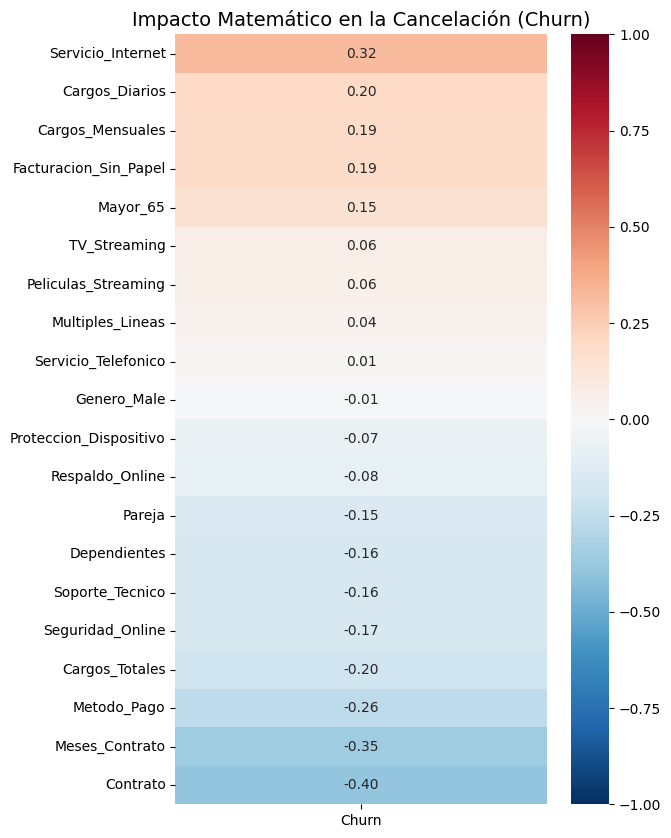

In [27]:
# ==========================================
# 6. ANÁLISIS DE CORRELACIÓN (El Radar)
# ==========================================
# Calculamos la matriz matemática de todas contra todas
matriz_corr = df.corr()

# Aislamos solo la columna Churn, la ordenamos de mayor a menor y borramos el Churn vs Churn (que es 1)
corr_churn = matriz_corr[['Churn']].sort_values(by='Churn', ascending=False).drop('Churn')

# Dibujamos un Heatmap (Mapa de Calor) enfocado 100% en la cancelación
plt.figure(figsize=(6, 10))
sns.heatmap(corr_churn, annot=True, cmap='RdBu_r', fmt=".2f", vmin=-1, vmax=1)
plt.title('Impacto Matemático en la Cancelación (Churn)', fontsize=14)

plt.savefig('./images/correlation_heatmap.png', bbox_inches='tight')
plt.show() # Este ya lo tienes

plt.show()

### **Análisis Dirigido**

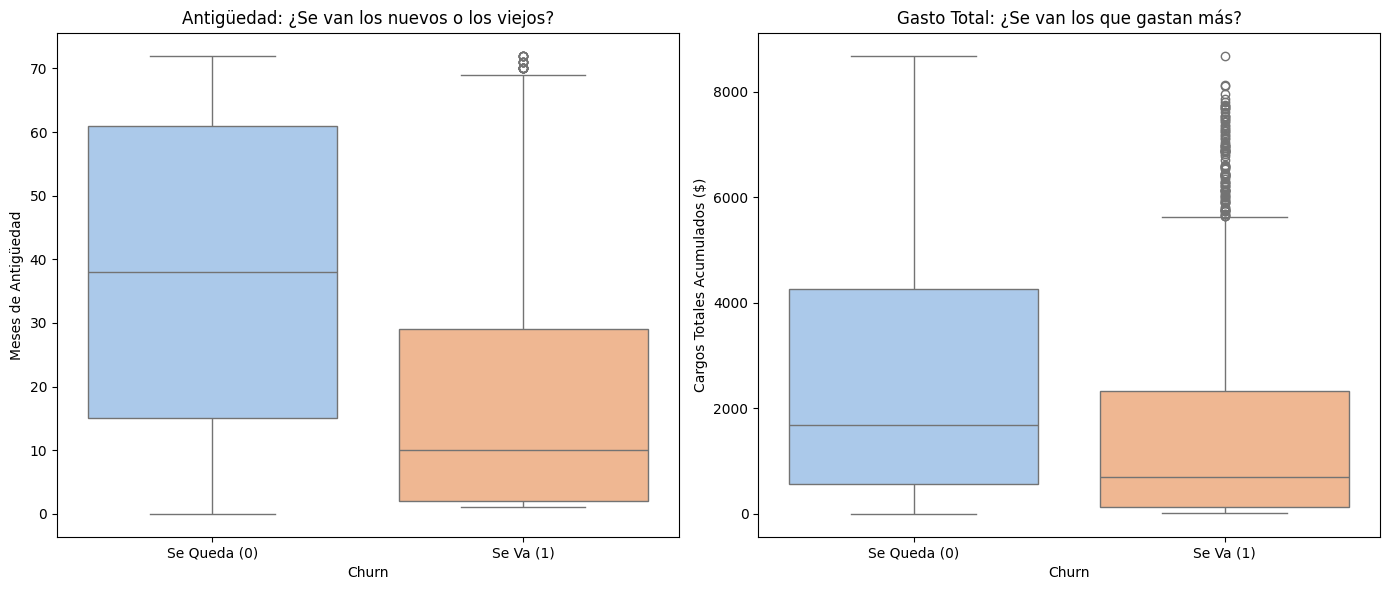

In [34]:
# ==========================================
# 7. ANÁLISIS DIRIGIDO (Boxplots) - VERSIÓN LIMPIA
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Tiempo de Contrato vs Cancelación
sns.boxplot(x='Churn', y='Meses_Contrato', data=df, ax=ax[0], hue='Churn', palette='pastel', legend=False)
ax[0].set_title('Antigüedad: ¿Se van los nuevos o los viejos?', fontsize=12)
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Se Queda (0)', 'Se Va (1)'])
ax[0].set_ylabel('Meses de Antigüedad')

# Gráfico 2: Gasto Total vs Cancelación
sns.boxplot(x='Churn', y='Cargos_Totales', data=df, ax=ax[1], hue='Churn', palette='pastel', legend=False)
ax[1].set_title('Gasto Total: ¿Se van los que gastan más?', fontsize=12)
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['Se Queda (0)', 'Se Va (1)'])
ax[1].set_ylabel('Cargos Totales Acumulados ($)')

plt.savefig('./images/boxplots_churn.png', bbox_inches='tight')

plt.tight_layout()
plt.show()

## **Modelado Predictivo**

### **Creación y evaluación de Modelos**

🤖 Entrenando: Regresión Logística...
🤖 Entrenando: Random Forest...


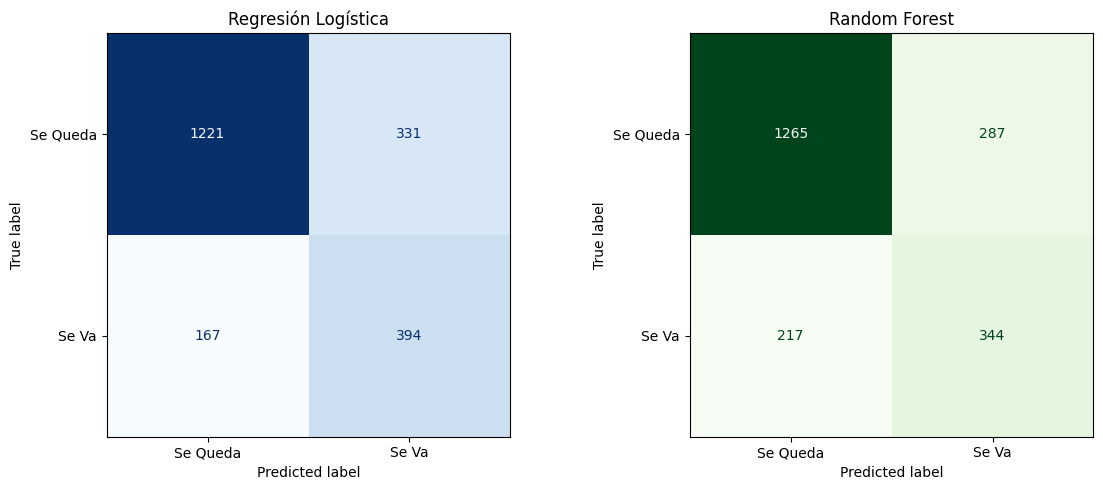


📊 REPORTE DE MÉTRICAS: REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

Se Queda (0)       0.88      0.79      0.83      1552
   Se Va (1)       0.54      0.70      0.61       561

    accuracy                           0.76      2113
   macro avg       0.71      0.74      0.72      2113
weighted avg       0.79      0.76      0.77      2113


📊 REPORTE DE MÉTRICAS: RANDOM FOREST
              precision    recall  f1-score   support

Se Queda (0)       0.85      0.82      0.83      1552
   Se Va (1)       0.55      0.61      0.58       561

    accuracy                           0.76      2113
   macro avg       0.70      0.71      0.71      2113
weighted avg       0.77      0.76      0.77      2113



In [37]:
# ==========================================
# 8. ENTRENAMIENTO DE MODELOS (El Cuadrilátero)
# ==========================================

# --- MODELO 1: Regresión Logística (Requiere Normalización) ---
print("🤖 Entrenando: Regresión Logística...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_norm, y_train_bal)
y_pred_lr = lr_model.predict(X_test_norm)

# --- MODELO 2: Random Forest (NO requiere Normalización) ---
print("🤖 Entrenando: Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# OJO: Le pasamos los datos balanceados, pero en su escala original
rf_model.fit(X_train_bal, y_train_bal) 
y_pred_rf = rf_model.predict(X_test)

# ==========================================
# 9. EVALUACIÓN DE LOS MODELOS (El Veredicto)
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Matriz para Regresión Logística
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Se Queda', 'Se Va'])
disp_lr.plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Regresión Logística')

# Matriz para Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Se Queda', 'Se Va'])
disp_rf.plot(ax=ax[1], cmap='Greens', colorbar=False)
ax[1].set_title('Random Forest')

plt.tight_layout()

plt.savefig('./images/confusion_matrix.png', bbox_inches='tight')

plt.show()

# Reportes de texto
print("\n" + "="*55)
print("📊 REPORTE DE MÉTRICAS: REGRESIÓN LOGÍSTICA")
print("="*55)
print(classification_report(y_test, y_pred_lr, target_names=['Se Queda (0)', 'Se Va (1)']))

print("\n" + "="*55)
print("📊 REPORTE DE MÉTRICAS: RANDOM FOREST")
print("="*55)
print(classification_report(y_test, y_pred_rf, target_names=['Se Queda (0)', 'Se Va (1)']))

plt.show()


## **Interpretación y Conlusiones**

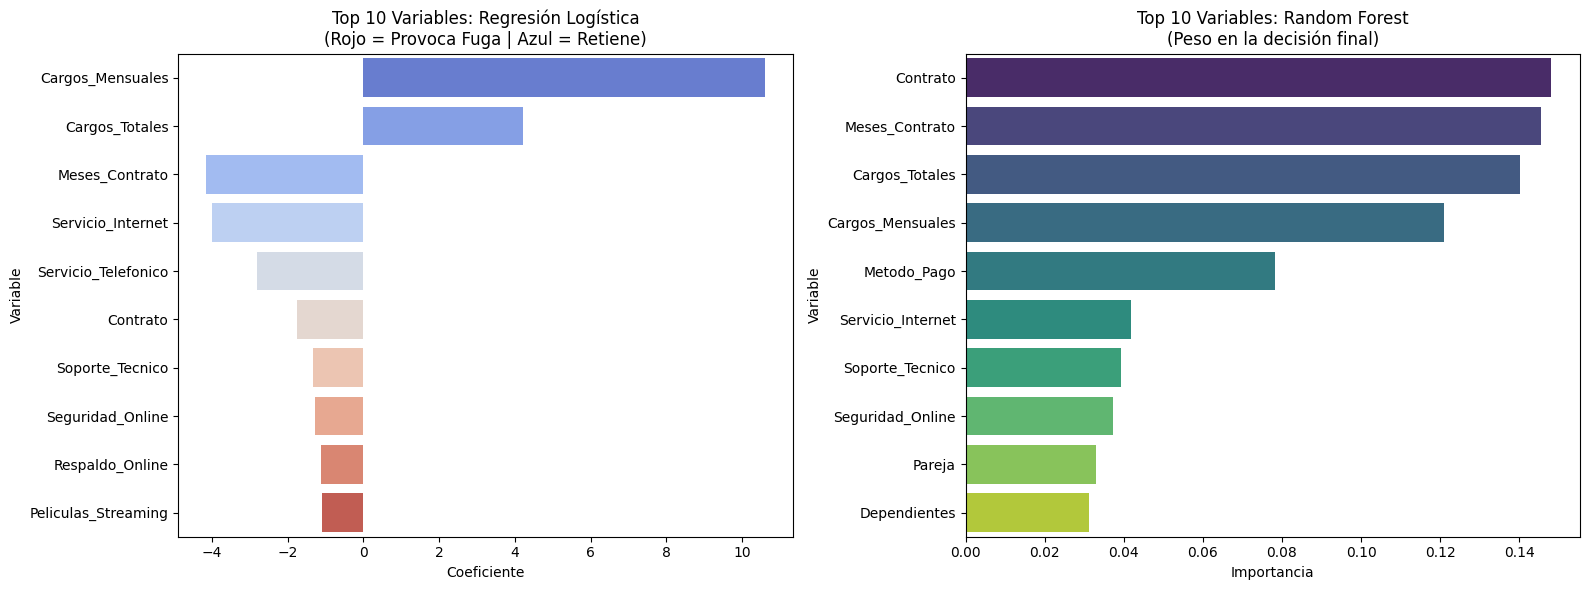

In [35]:
# ==========================================
# 10. IMPORTANCIA DE LAS VARIABLES (La Autopsia)
# ==========================================

# --- 1. Regresión Logística (Coeficientes) ---
# Extraemos los pesos matemáticos. 
# Valores Positivos (+) = Empujan al cliente a cancelar
# Valores Negativos (-) = Amarran al cliente para que se quede
importancia_lr = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lr_model.coef_[0]
})
# Ordenamos por impacto absoluto para ver los más fuertes (positivos o negativos)
importancia_lr['Impacto_Absoluto'] = importancia_lr['Coeficiente'].abs()
importancia_lr = importancia_lr.sort_values(by='Impacto_Absoluto', ascending=False).head(10)

# --- 2. Random Forest (Feature Importances) ---
# RF no dice si es positivo o negativo, solo dice "Qué tan importante fue esta variable para decidir"
importancia_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False).head(10)

# --- 3. Graficamos el veredicto lado a lado ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico Logística
sns.barplot(x='Coeficiente', y='Variable', data=importancia_lr, ax=ax[0], hue='Variable', palette='coolwarm', legend=False)
ax[0].set_title('Top 10 Variables: Regresión Logística\n(Rojo = Provoca Fuga | Azul = Retiene)', fontsize=12)

# Gráfico Random Forest
sns.barplot(x='Importancia', y='Variable', data=importancia_rf, ax=ax[1], hue='Variable', palette='viridis', legend=False)
ax[1].set_title('Top 10 Variables: Random Forest\n(Peso en la decisión final)', fontsize=12)

plt.tight_layout()

plt.savefig('./images/feature_importance_ml.png', bbox_inches='tight')

plt.show()

### **Informe Final**

## 🎯 Conclusión Estratégica y Recomendaciones de Negocio

Tras evaluar múltiples algoritmos de Machine Learning, el modelo de **Regresión Logística** demostró ser el más efectivo para los objetivos de Telecom X, logrando un **Recall del 70%** en la detección de clientes propensos a cancelar (Churn), superando la capacidad predictiva del Random Forest.

### 🔍 Principales Detonantes de la Cancelación (Insights)
Al analizar los coeficientes del modelo ganador, descubrimos que la fuga de clientes no es aleatoria. Los principales factores matemáticos son:
1. **La trampa del corto plazo:** Los clientes con `Contratos Mensuales` y menor tiempo de antigüedad (`Meses_Contrato`) tienen la mayor probabilidad de abandonar el servicio. No existe un "anclaje" fuerte a la empresa.
2. **El problema de la Fibra Óptica:** El servicio de `Internet de Fibra Óptica` tiene una correlación sorprendentemente alta con la cancelación. Esto sugiere que el servicio podría ser demasiado costoso para el valor percibido, o que presenta interrupciones técnicas constantes que frustran al usuario.
3. **Falta de ecosistema:** Los clientes que NO tienen servicios adicionales contratados (como `Seguridad_Online` o `Soporte_Tecnico`) son altamente volátiles.

### 🚀 Estrategias de Retención Propuestas
Basado en esta inteligencia predictiva, se recomienda a la directiva de Telecom X implementar las siguientes acciones para reducir la tasa del 26.5% de fuga:
* **Campaña de Migración de Contratos:** Ofrecer descuentos agresivos en los primeros 3 meses a los clientes de facturación mensual si deciden firmar un contrato anual, forzando la retención temprana.
* **Auditoría de la Fibra Óptica:** Iniciar una revisión técnica y de precios urgente en el servicio de Fibra Óptica, ya que actualmente está actuando como un expulsor de clientes en lugar de un producto premium.
* **Bundles (Paquetes) Defensivos:** Regalar 3 meses de `Seguridad Online` o `Soporte Técnico Premium` a los nuevos usuarios. El modelo demuestra que entre más servicios entrelazados tiene el cliente en su paquete, más fricción existe para que migre a la competencia.